## Integração

Aluno - Keanu Frota Sales / Matrícula - 202104940028

#### Imports

In [1]:
from numpy import linspace, zeros, arange, ndarray
from matplotlib.pyplot import figure, rc
from itertools import count
from typing import Callable
from numpy import sin, pi

#### Ajuste de Curva

In [2]:
class CurveAdjust:
  def __init__(self, D: ndarray, I: ndarray, inter: tuple[int, int], m: int, n: int):
    self.inter, self.m, self.n = inter, m, n
    self.G = G = D.reshape(-1, 1) ** arange(n)
    self.A, self.B = (G.T @ G), (G.T @ I)
    self.fatoraçãoLU()

  def fatoraçãoLU(self):
    L = zeros((self.n, self.n))
    L.flat[::self.n + 1] = 1
    U = self.A

    for i1, i2 in zip(count(), count(1)):
      if not (self.n - i2): break
      L[i2:, i1] = U[i2:, i1] / U[i1, i1]
      U[i2:] -= L[i2:, i1, None] * U[i1]

    x, y = zeros(self.n), zeros(self.n)

    for i in arange(self.n):
      y[i] = self.B[i] - sum(L[i] * y)
    for i in arange(self.n)[::-1]:
      x[i] = (y[i] - sum(U[i] * x)) / U[i, i]

    i1, i2 = self.inter
    self.RD = D = linspace(i1, i2, self.m)
    self.RI = (D.reshape(-1, 1) ** arange(self.n)) @ x

#### Integração

In [3]:
class Integral:
  def __init__(self, func: Callable, inter: tuple[int, int], n: int, e = 1e-15):
    (i1, i2), self.func, self.e = inter, func, e
    D = linspace(i1, i2, n)
    P1, P2 = self.trapezio(D), self.simpson(D)

    ajuste1 = CurveAdjust(D, P1, inter, 1000, 15)
    ajuste2 = CurveAdjust(D, P2, inter, 1000, 15)
    self.F1 = (D, P1, ajuste1.RD, ajuste1.RI)
    self.F2 = (D, P2, ajuste2.RD, ajuste2.RI)

    self.plotgfx()

  def trapezio(self, D: ndarray):
    func, e = self.func, self.e
    return e * (func(D - e) + func(D + e))

  def simpson(self, D: ndarray):
    func, e = self.func, self.e
    return (2/3) * e * (func(D - e) + 4 * func(D) + func(D + e))

  def plotgfx(self):
    rc("font", family = "Consolas", size = 7.5)
    rc("lines", aa = 1, lw = .5, markersize = 2)

    fig = figure(figsize = (12, 3))
    axes = fig.subplots(1, 2)
    fig.dpi = 400

    for (i, (D1, I1, D2, I2)) in enumerate((self.F1, self.F2)):
      axes[i].plot(D2, I2, label = "Integral", c = "k")
      axes[i].scatter(D1, I1, label = "Integral", c = "r")
      axes[i].set_xlabel("Domínio da função")
      axes[i].set_ylabel("Imagem da função")
      axes[i].legend()

    fig.suptitle("Integralização da Função")
    fig.tight_layout(pad = 1)

#### Execução com os resultados

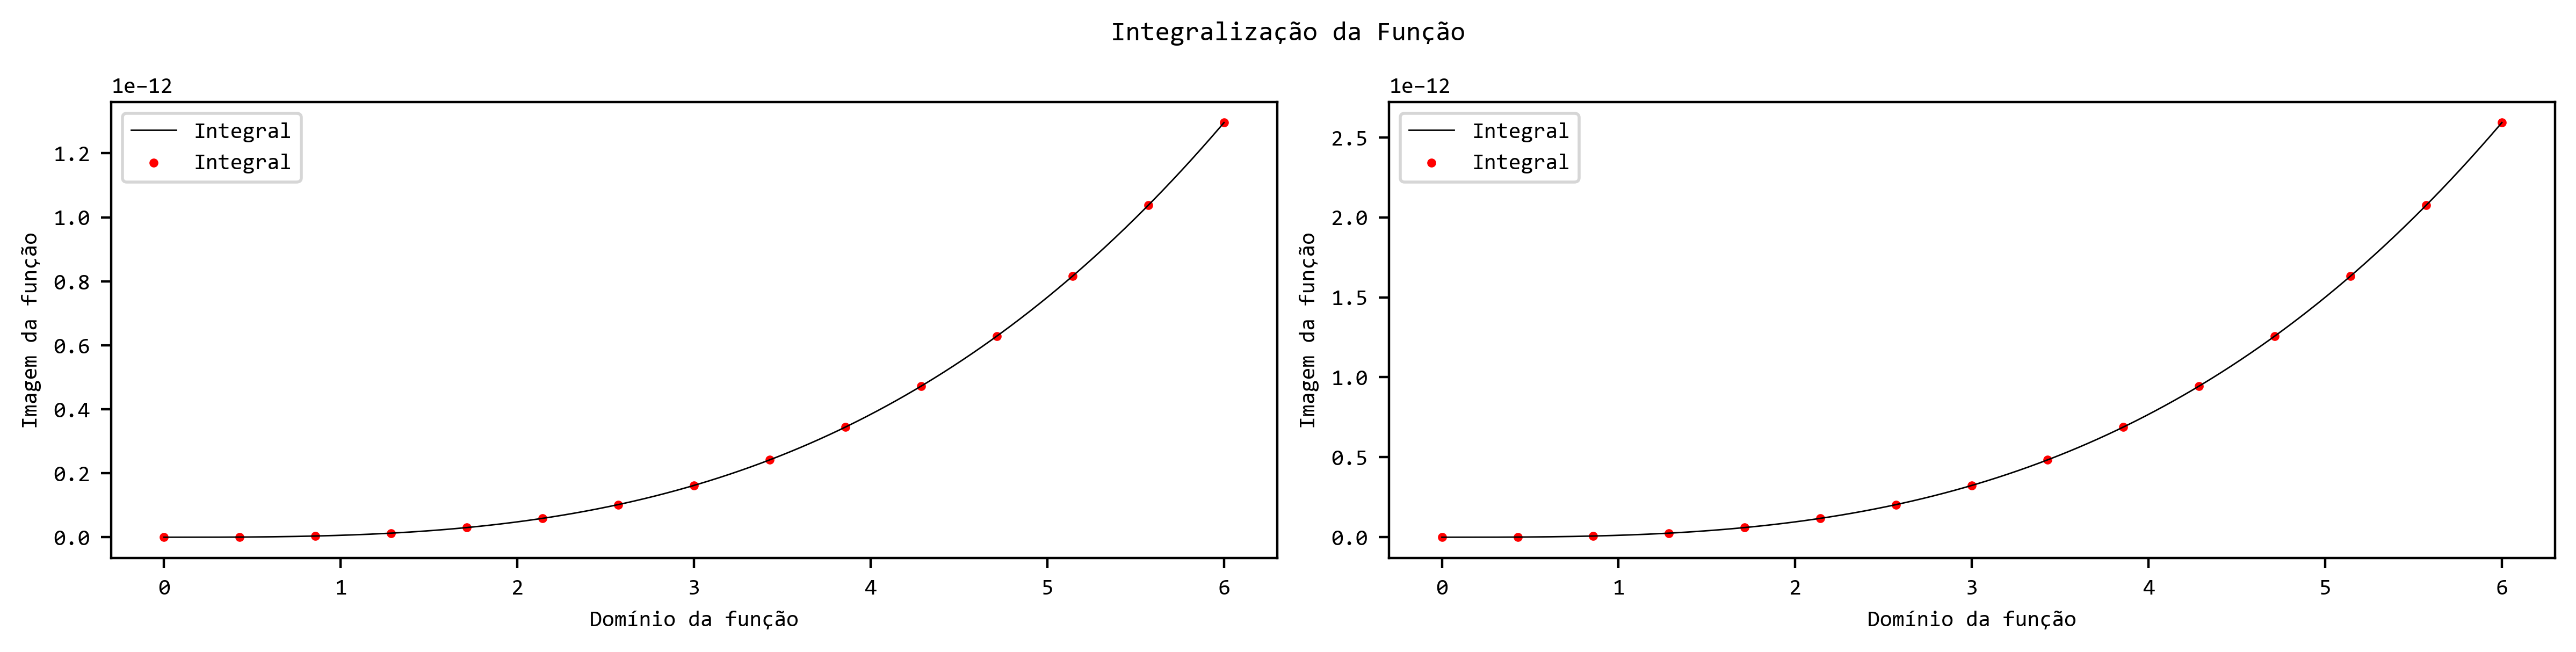

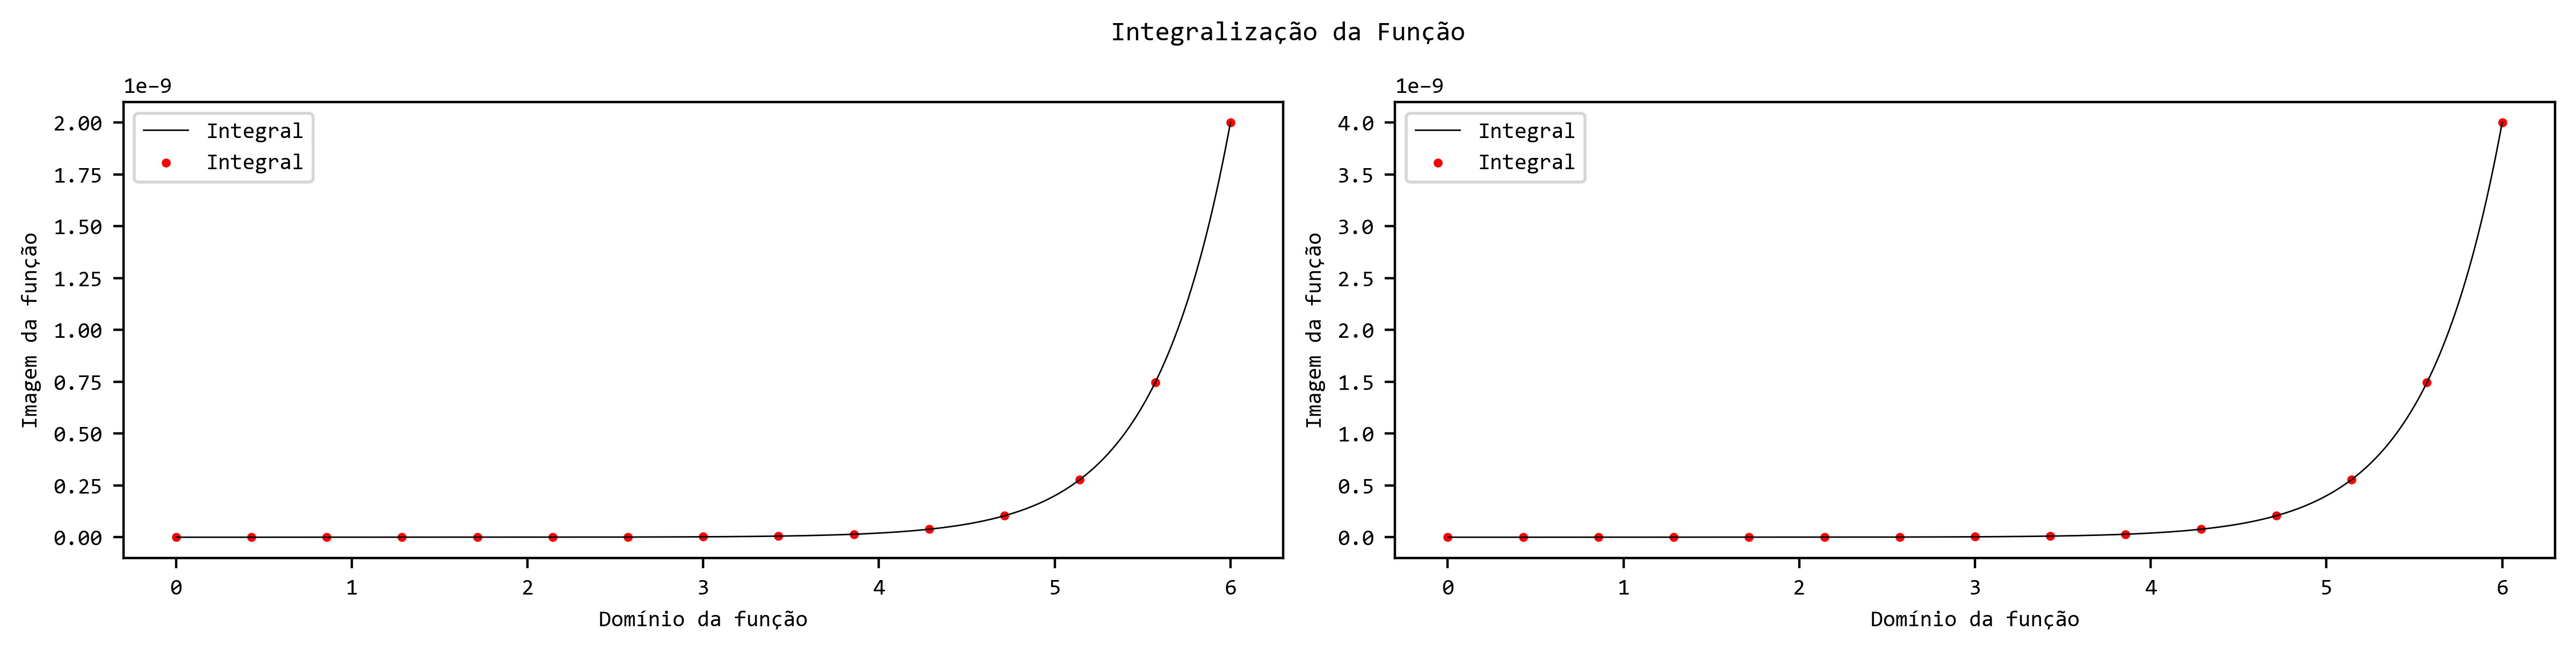

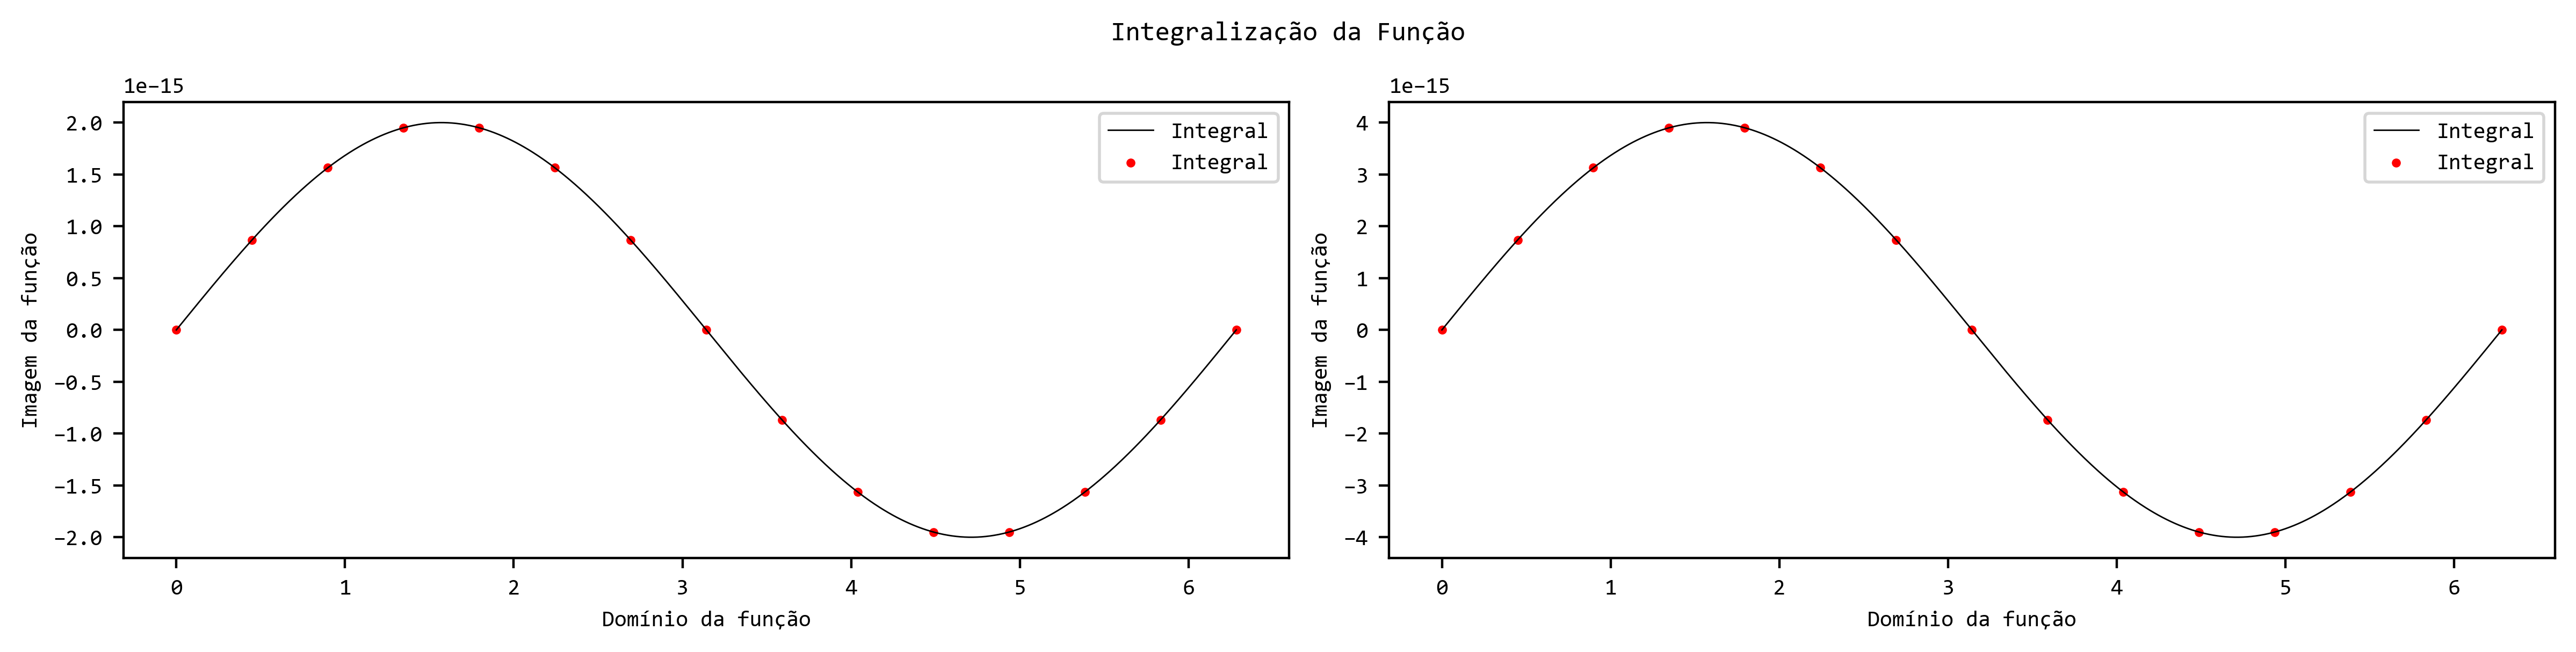

In [4]:
Integral(lambda x: 3*x**3, (0, 6), 15)
Integral(lambda x: 10**x, (0, 6), 15)
Integral(lambda x: sin(x), (0, 2*pi), 15)
pass